# OMIA Post-Inference EDA + All-Species Concatenation
This notebook performs post-inference quality checks, exploratory summaries, and export of cleaned all-species outputs.

Result files loaded per species:
- `data/results/dog_deltas.parquet` 
- `data/results/cat_deltas.parquet` 
- `data/results/chicken_deltas.parquet`

Output artifacts:
- `data/results/omia_all_species_inferred_full.parquet`
- `data/results/omia_all_species_inferred_relevant.parquet`
- `data/results/omia_post_inference_summary.csv`

Validation scope: key coverage, duplicates, schema counts, bounds checks, and label/species sanity.

In [1]:
from pathlib import Path
from typing import Optional, Dict, Tuple
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

KEY_COLS = ["chrom", "pos", "ref", "alt"]
SPECIES_FILES = {
    "dog": "dog_deltas.parquet",
    "cat": "cat_deltas.parquet",
    "chicken": "chicken_deltas.parquet",
}
# FALLBACK_SUFFIX = "_sample30.parquet" # deprecate


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.json").exists() and (candidate / "data").exists():
            return candidate
    if start.name == "data" and start.parent.exists():
        return start.parent
    raise FileNotFoundError(
        "Could not infer repo root. Run from repo root or its data/ subfolder."
    )


def choose_result_path(results_dir: Path, filename: str) -> Tuple[Path, str]:
    full_path = results_dir / filename
    # fallback_path = results_dir / filename.replace(".parquet", FALLBACK_SUFFIX)
    if full_path.exists():
        return full_path, "full"
    raise FileNotFoundError(f"Missing  {full_path.name} in {results_dir}")


def _find_column(df: pd.DataFrame, canonical_name: str) -> Optional[str]:
    synonyms = {
        "chrom": ["chrom", "chr", "chromosome", "#chrom", "chromosome_name"],
        "pos": ["pos", "position", "bp", "start"],
        "ref": ["ref", "reference", "ref_allele"],
        "alt": ["alt", "alternate", "alt_allele"],
    }
    lookup = {c.lower(): c for c in df.columns}
    for candidate in synonyms[canonical_name]:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


def standardize_key_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    for canonical in KEY_COLS:
        if canonical not in df.columns:
            original = _find_column(df, canonical)
            if original is not None and original != canonical:
                rename_map[original] = canonical
    if rename_map:
        df = df.rename(columns=rename_map)

    for col in KEY_COLS:
        if col not in df.columns:
            df[col] = pd.NA

    df["chrom"] = (
        df["chrom"].astype("string").str.replace(r"^chr", "", regex=True).str.strip()
    )
    df["ref"] = df["ref"].astype("string").str.upper().str.strip()
    df["alt"] = df["alt"].astype("string").str.upper().str.strip()
    df["pos"] = pd.to_numeric(df["pos"], errors="coerce").astype("Int64")
    return df


def key_complete_mask(df: pd.DataFrame) -> pd.Series:
    return df[KEY_COLS].notna().all(axis=1)


def build_variant_key(df: pd.DataFrame) -> pd.Series:
    return (
        df["chrom"].astype("string")
        + ":"
        + df["pos"].astype("string")
        + ":"
        + df["ref"].astype("string")
        + ">"
        + df["alt"].astype("string")
    )


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Results dir: {RESULTS_DIR}")

Repo root: /opt/hpc/ddofer/magi_genome
Results dir: /opt/hpc/ddofer/magi_genome/data/results


In [2]:
loaded_frames: Dict[str, pd.DataFrame] = {}
load_rows = []

for species_key, filename in SPECIES_FILES.items():
    selected_path, variant = choose_result_path(RESULTS_DIR, filename)
    df_species = pd.read_parquet(selected_path)
    df_species = standardize_key_columns(df_species)
    df_species["species_key"] = species_key
    if "species" not in df_species.columns:
        df_species["species"] = species_key
    loaded_frames[species_key] = df_species

    load_rows.append(
        {
            "species_key": species_key,
            "selected_file": selected_path.name,
            "mode": variant,
            "rows": len(df_species),
            "columns": df_species.shape[1],
        }
    )

load_report = pd.DataFrame(load_rows).sort_values("species_key").reset_index(drop=True)
display(load_report)

all_species_raw = pd.concat(list(loaded_frames.values()), ignore_index=True, sort=False)
all_species_raw = standardize_key_columns(all_species_raw)
all_species_raw["species_key"] = all_species_raw["species_key"].astype("string")
all_species_raw["variant_key"] = pd.NA
all_species_raw.loc[key_complete_mask(all_species_raw), "variant_key"] = (
    build_variant_key(
        all_species_raw.loc[key_complete_mask(all_species_raw), KEY_COLS]
    ).values
)

print(f"Combined rows: {len(all_species_raw):,}")
print(f"Combined columns: {all_species_raw.shape[1]:,}")

,species_key,selected_file,mode,rows,columns
0,cat,cat_deltas.parquet,full,185,67
1,chicken,chicken_deltas.parquet,full,35,67
2,dog,dog_deltas.parquet,full,360,67


Combined rows: 580
Combined columns: 68


In [3]:
species_overview_rows = []
for species_key, df_species in loaded_frames.items():
    complete_mask = key_complete_mask(df_species)
    unique_keys = df_species.loc[complete_mask, KEY_COLS].drop_duplicates().shape[0]
    species_overview_rows.append(
        {
            "species_key": species_key,
            "rows": len(df_species),
            "rows_with_complete_key": int(complete_mask.sum()),
            "rows_missing_any_key": int((~complete_mask).sum()),
            "unique_key_count": int(unique_keys),
        }
    )

species_overview = pd.DataFrame(species_overview_rows).sort_values("species_key")
display(species_overview)

preview_cols = [
    c
    for c in [*KEY_COLS, "species", "species_key", "label", "LLR", "variant_key"]
    if c in all_species_raw.columns
]
display(all_species_raw[preview_cols].head(10))

,species_key,rows,rows_with_complete_key,rows_missing_any_key,unique_key_count
1,cat,185,185,0,185
2,chicken,35,35,0,35
0,dog,360,360,0,360


,chrom,pos,ref,alt,species,species_key,label,LLR,variant_key
0,6,55146556,-,N,canis_lupus_familiaris,dog,True,NaN,6:55146556:->N
1,14,13726596,N,-,canis_lupus_familiaris,dog,True,NaN,14:13726596:N>-
2,14,13742402,A,C,canis_lupus_familiaris,dog,True,0.162919,14:13742402:A>C
3,23,2587000,N,-,canis_lupus_familiaris,dog,True,NaN,23:2587000:N>-
4,5,32193689,C,A,canis_lupus_familiaris,dog,True,-1.671284,5:32193689:C>A
5,1,106051997,-,C,canis_lupus_familiaris,dog,True,NaN,1:106051997:->C
6,28,23380074,N,-,canis_lupus_familiaris,dog,True,NaN,28:23380074:N>-
7,20,53096339,C,T,canis_lupus_familiaris,dog,True,-2.022068,20:53096339:C>T
8,20,53101896,C,T,canis_lupus_familiaris,dog,True,-2.542818,20:53101896:C>T
9,3,40614853,N,-,canis_lupus_familiaris,dog,True,NaN,3:40614853:N>-


In [4]:
input_candidates = [
    DATA_DIR / "omia_raw_variants.csv",
    REPO_ROOT / "omia_raw_variants.csv",
]
input_path = next((p for p in input_candidates if p.exists()), None)

if input_path is None:
    warnings.warn(
        "Input OMIA variants CSV not found; key coverage vs input will be skipped."
    )
    input_keys = pd.DataFrame(columns=[*KEY_COLS, "variant_key"])
else:
    input_df = pd.read_csv(input_path)
    input_df = standardize_key_columns(input_df)
    input_df = (
        input_df.loc[key_complete_mask(input_df), KEY_COLS].drop_duplicates().copy()
    )
    input_df["variant_key"] = build_variant_key(input_df)
    input_keys = input_df
    print(f"Input variants loaded from: {input_path}")
    print(f"Input unique complete keys: {len(input_keys):,}")

output_keys = (
    all_species_raw.loc[key_complete_mask(all_species_raw), [*KEY_COLS, "species_key"]]
    .drop_duplicates()
    .copy()
)
output_keys["variant_key"] = build_variant_key(output_keys)

if len(input_keys) > 0:
    input_key_set = set(input_keys["variant_key"].astype(str))
    output_key_set = set(output_keys["variant_key"].astype(str))
    coverage_summary = pd.DataFrame(
        [
            {
                "input_unique_keys": len(input_key_set),
                "output_unique_keys": len(output_key_set),
                "input_keys_found_in_output": len(input_key_set & output_key_set),
                "input_coverage_ratio": len(input_key_set & output_key_set)
                / max(len(input_key_set), 1),
                "output_keys_matching_input": len(input_key_set & output_key_set),
                "output_overlap_ratio": len(input_key_set & output_key_set)
                / max(len(output_key_set), 1),
            }
        ]
    )
    display(coverage_summary)
else:
    coverage_summary = pd.DataFrame(
        [
            {
                "input_unique_keys": np.nan,
                "output_unique_keys": output_keys["variant_key"].nunique(),
                "input_keys_found_in_output": np.nan,
                "input_coverage_ratio": np.nan,
                "output_keys_matching_input": np.nan,
                "output_overlap_ratio": np.nan,
            }
        ]
    )
    display(coverage_summary)

dup_rows = []
for species_key, df_species in loaded_frames.items():
    complete = df_species.loc[key_complete_mask(df_species), KEY_COLS].copy()
    dup_mask = complete.duplicated(subset=KEY_COLS, keep=False)
    dup_rows.append(
        {
            "scope": species_key,
            "rows_with_complete_key": int(len(complete)),
            "duplicate_rows": int(dup_mask.sum()),
            "duplicate_unique_keys": int(
                complete.loc[dup_mask, KEY_COLS].drop_duplicates().shape[0]
            ),
        }
    )

all_complete = all_species_raw.loc[
    key_complete_mask(all_species_raw), ["species_key", *KEY_COLS]
].copy()
all_dup_mask = all_complete.duplicated(subset=["species_key", *KEY_COLS], keep=False)
dup_rows.append(
    {
        "scope": "all_species_combined",
        "rows_with_complete_key": int(len(all_complete)),
        "duplicate_rows": int(all_dup_mask.sum()),
        "duplicate_unique_keys": int(
            all_complete.loc[all_dup_mask, ["species_key", *KEY_COLS]]
            .drop_duplicates()
            .shape[0]
        ),
    }
)

duplicate_summary = pd.DataFrame(dup_rows)
display(duplicate_summary)

Input variants loaded from: /opt/hpc/ddofer/magi_genome/data/omia_raw_variants.csv
Input unique complete keys: 0


,input_unique_keys,output_unique_keys,input_keys_found_in_output,input_coverage_ratio,output_keys_matching_input,output_overlap_ratio
0,NaN,580,NaN,NaN,NaN,NaN


,scope,rows_with_complete_key,duplicate_rows,duplicate_unique_keys
0,dog,360,0,0
1,cat,185,0,0
2,chicken,35,0,0
3,all_species_combined,580,0,0


In [5]:
ref_bed_cols = [c for c in all_species_raw.columns if c.startswith("REF_BED_")]
d_bed_cols = [c for c in all_species_raw.columns if c.startswith("D_BED_")]
bw_cols = [c for c in all_species_raw.columns if "BW" in c.upper()]
mlm_cols = [c for c in all_species_raw.columns if "MLM" in c.upper()]

feature_schema_counts = pd.DataFrame(
    [
        {"feature_group": "REF_BED_*", "n_columns": len(ref_bed_cols)},
        {"feature_group": "D_BED_*", "n_columns": len(d_bed_cols)},
        {"feature_group": "BW", "n_columns": len(bw_cols)},
        {"feature_group": "MLM", "n_columns": len(mlm_cols)},
    ]
)
display(feature_schema_counts)


def bounds_check(
    df: pd.DataFrame, cols, low: float, high: float, group_name: str
) -> pd.DataFrame:
    if not cols:
        return pd.DataFrame(
            columns=["group", "column", "non_null", "violations", "violation_rate"]
        )
    numeric = df[cols].apply(pd.to_numeric, errors="coerce")
    rows = []
    for col in cols:
        col_values = numeric[col]
        non_null = int(col_values.notna().sum())
        violations = int(((col_values < low) | (col_values > high)).sum())
        rows.append(
            {
                "group": group_name,
                "column": col,
                "non_null": non_null,
                "violations": violations,
                "violation_rate": violations / max(non_null, 1),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["violations", "violation_rate"], ascending=False
    )


ref_bounds = bounds_check(all_species_raw, ref_bed_cols, 0.0, 1.0, "REF_BED")
d_bounds = bounds_check(all_species_raw, d_bed_cols, -1.0, 1.0, "D_BED")

print(
    "REF_BED bound violations:",
    int(ref_bounds["violations"].sum()) if not ref_bounds.empty else 0,
)
print(
    "D_BED bound violations:",
    int(d_bounds["violations"].sum()) if not d_bounds.empty else 0,
)

display(ref_bounds.head(15))
display(d_bounds.head(15))

,feature_group,n_columns
0,REF_BED_*,21
1,D_BED_*,21
2,BW,0
3,MLM,7


REF_BED bound violations: 0
D_BED bound violations: 0


,group,column,non_null,violations,violation_rate
0,REF_BED,REF_BED_protein_coding_gene,580,0,0.0
1,REF_BED,REF_BED_lncRNA,580,0,0.0
2,REF_BED,REF_BED_exon,580,0,0.0
3,REF_BED,REF_BED_intron,580,0,0.0
4,REF_BED,REF_BED_splice_donor,580,0,0.0
5,REF_BED,REF_BED_splice_acceptor,580,0,0.0
6,REF_BED,REF_BED_CTCF-bound,580,0,0.0
7,REF_BED,REF_BED_polyA_signal,580,0,0.0
8,REF_BED,REF_BED_enhancer_Tissue_specific,580,0,0.0
9,REF_BED,REF_BED_enhancer_Tissue_invariant,580,0,0.0


,group,column,non_null,violations,violation_rate
0,D_BED,D_BED_protein_coding_gene,580,0,0.0
1,D_BED,D_BED_lncRNA,580,0,0.0
2,D_BED,D_BED_exon,580,0,0.0
3,D_BED,D_BED_intron,580,0,0.0
4,D_BED,D_BED_splice_donor,580,0,0.0
5,D_BED,D_BED_splice_acceptor,580,0,0.0
6,D_BED,D_BED_CTCF-bound,580,0,0.0
7,D_BED,D_BED_polyA_signal,580,0,0.0
8,D_BED,D_BED_enhancer_Tissue_specific,580,0,0.0
9,D_BED,D_BED_enhancer_Tissue_invariant,580,0,0.0


In [6]:
expected_species = set(SPECIES_FILES.keys())
observed_species_key = set(
    all_species_raw["species_key"].dropna().astype(str).str.lower().unique()
)
species_key_missing = sorted(expected_species - observed_species_key)
species_key_unexpected = sorted(observed_species_key - expected_species)

species_sanity = pd.DataFrame(
    [
        {
            "expected_species": ", ".join(sorted(expected_species)),
            "observed_species_key": ", ".join(sorted(observed_species_key)),
            "missing_species_key": ", ".join(species_key_missing)
            if species_key_missing
            else "",
            "unexpected_species_key": ", ".join(species_key_unexpected)
            if species_key_unexpected
            else "",
        }
    ]
)
display(species_sanity)

if "species" in all_species_raw.columns:
    species_alignment = (
        all_species_raw["species"].astype("string").str.lower().str.strip()
        == all_species_raw["species_key"].astype("string").str.lower().str.strip()
    )
    print(
        "Species/species_key mismatches:", int((~species_alignment.fillna(False)).sum())
    )
else:
    print("Column 'species' not present; species sanity based on species_key only.")

if "label" in all_species_raw.columns:
    label_summary = (
        all_species_raw.groupby(["species_key", "label"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["species_key", "label"])
    )
    display(label_summary)
    print(
        "Distinct label values:",
        sorted(all_species_raw["label"].dropna().astype(str).unique().tolist()),
    )
else:
    label_summary = pd.DataFrame(columns=["species_key", "label", "count"])
    warnings.warn("Column 'label' not present in inferred outputs.")

,expected_species,observed_species_key,missing_species_key,unexpected_species_key
0,"cat, chicken, dog","cat, chicken, dog",,


Species/species_key mismatches: 580


,species_key,label,count
0,cat,True,185
1,chicken,True,35
2,dog,True,360


Distinct label values: ['True']


/tmp/ipykernel_1825728/648815833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=species_counts, x="species_key", y="rows", palette="deep")


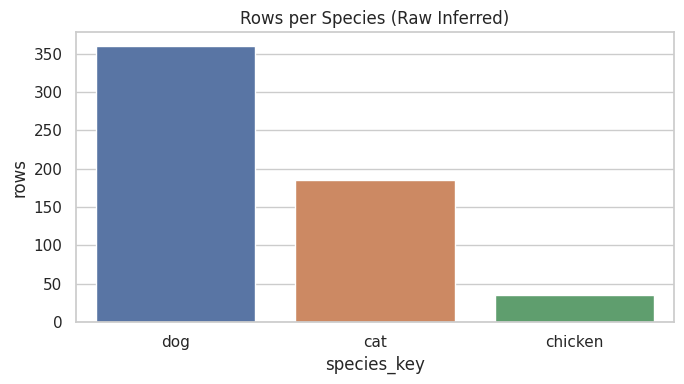

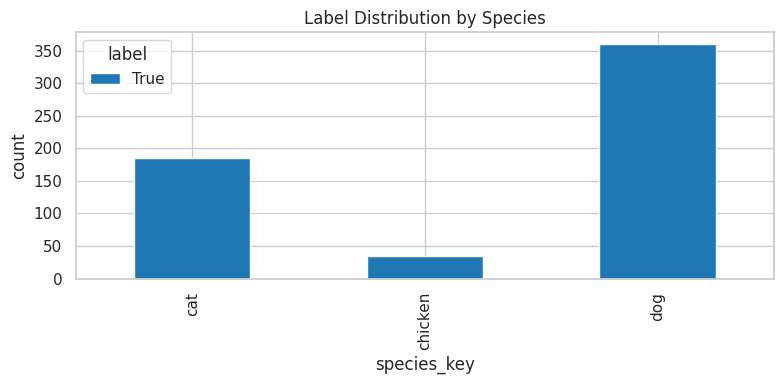

In [7]:
species_counts = (
    all_species_raw["species_key"]
    .value_counts(dropna=False)
    .rename_axis("species_key")
    .reset_index(name="rows")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=species_counts, x="species_key", y="rows", palette="deep")
plt.title("Rows per Species (Raw Inferred)")
plt.xlabel("species_key")
plt.ylabel("rows")
plt.tight_layout()
plt.show()

if not label_summary.empty:
    label_plot = label_summary.copy()
    label_plot["label"] = label_plot["label"].astype("string")
    pivot = label_plot.pivot(
        index="species_key", columns="label", values="count"
    ).fillna(0)
    pivot.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab20")
    plt.title("Label Distribution by Species")
    plt.xlabel("species_key")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping label distribution plot: 'label' data unavailable.")

,feature,mean_abs_delta
0,D_BED_ORF,0.029080
1,D_BED_stop_codon,0.024741
2,D_BED_exon,0.024702
3,D_BED_splice_donor,0.019966
4,D_BED_polyA_signal,0.019602
5,D_BED_always_on_exon,0.017184
6,D_BED_protein_coding_gene,0.017050
7,D_BED_start_codon,0.016849
8,D_BED_intron,0.016592
9,D_BED_splice_acceptor,0.015814


/tmp/ipykernel_1825728/4039255263.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


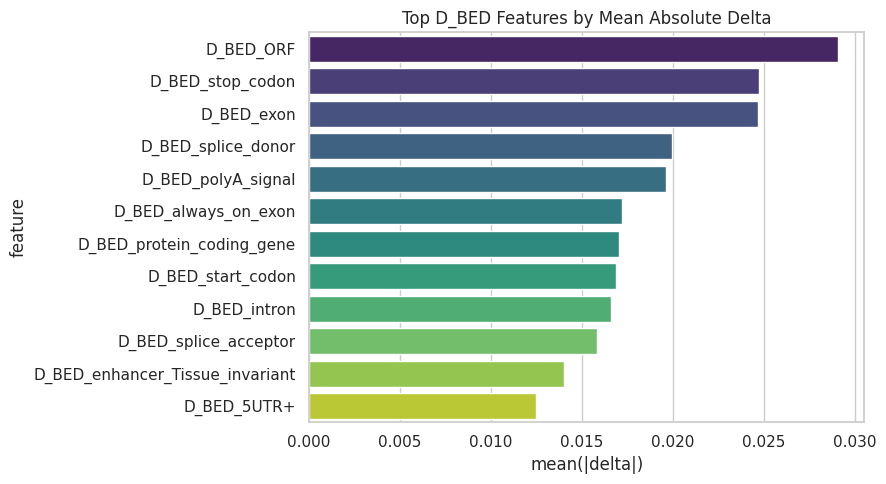

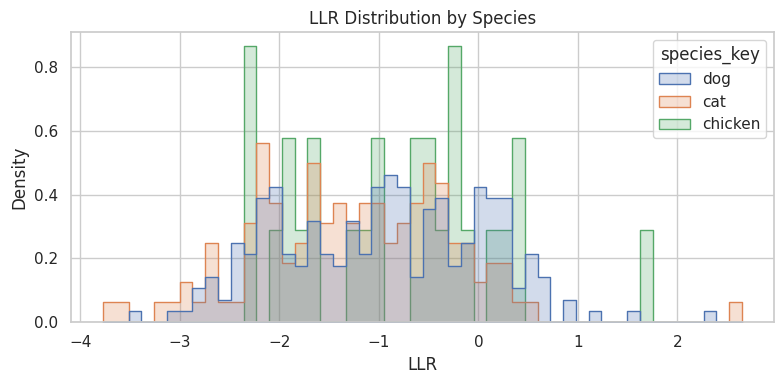

In [8]:
if d_bed_cols:
    d_bed_mean_abs = (
        all_species_raw[d_bed_cols]
        .apply(pd.to_numeric, errors="coerce")
        .abs()
        .mean()
        .sort_values(ascending=False)
    )
    top_d_bed_preview = (
        d_bed_mean_abs.head(12)
        .rename("mean_abs_delta")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    display(top_d_bed_preview)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=top_d_bed_preview, x="mean_abs_delta", y="feature", palette="viridis"
    )
    plt.title("Top D_BED Features by Mean Absolute Delta")
    plt.xlabel("mean(|delta|)")
    plt.ylabel("feature")
    plt.tight_layout()
    plt.show()
else:
    d_bed_mean_abs = pd.Series(dtype=float)
    print("No D_BED_* columns found.")

if "LLR" in all_species_raw.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=all_species_raw,
        x="LLR",
        hue="species_key",
        bins=50,
        element="step",
        stat="density",
        common_norm=False,
    )
    plt.title("LLR Distribution by Species")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'LLR' not found; skipping LLR distribution plot.")

In [9]:
clean_rows_before = len(all_species_raw)
clean_df = all_species_raw.copy()

# Enforce complete keys
clean_df = clean_df.loc[key_complete_mask(clean_df)].copy()

# Drop duplicate keys at species granularity
clean_df = clean_df.drop_duplicates(
    subset=["species_key", *KEY_COLS], keep="first"
).copy()

clean_df["variant_key"] = build_variant_key(clean_df)
clean_rows_after = len(clean_df)

cleaning_summary = pd.DataFrame(
    [
        {
            "rows_before": clean_rows_before,
            "rows_after": clean_rows_after,
            "rows_removed": clean_rows_before - clean_rows_after,
            "rows_retained_ratio": clean_rows_after / max(clean_rows_before, 1),
        }
    ]
)
display(cleaning_summary)

all_species_clean = clean_df

,rows_before,rows_after,rows_removed,rows_retained_ratio
0,580,580,0,1.0


In [10]:
# ── BigWig Tracks: Human-Only by Architecture ────────────────────────────────
#
# The NTv3 BigWig head uses a MultiSpeciesHead with separate LinearHead
# per species. Non-human species get ZeroHead → logit=0 → sigmoid=0.5
# constant for both ref and alt → delta always 0.0.
#
# Verified empirically: all D_BW_ values are exactly 0.0, all REF_BW_
# values are exactly 0.5 for dog/cat/chicken.
#
# BigWig features are therefore DISABLED for non-human OMIA inference.
# Only BED (21 shared elements) and MLM/KL features are meaningful.

bw_d_cols = [c for c in all_species_clean.columns if c.startswith("D_BW_")]
bw_r_cols = [c for c in all_species_clean.columns if c.startswith("REF_BW_")]
print(f"BigWig columns found:  {len(bw_d_cols)} D_BW_  |  {len(bw_r_cols)} REF_BW_")

if bw_d_cols:
    # Sanity check — should be all zeros
    bw_max = all_species_clean[bw_d_cols].abs().max().max()
    bw_r_unique = all_species_clean[bw_r_cols].nunique().sum() if bw_r_cols else -1
    print(f"D_BW max |delta|:  {bw_max:.6f}  (expected: 0.0 for non-human)")
    print(
        f"REF_BW unique values total: {bw_r_unique}  (expected: ≤1 per col for non-human = 0.5 constant)"
    )
    if bw_max == 0.0:
        print("✅ Confirmed: BigWig deltas are all 0.0 (ZeroHead architecture)")
        print("   Dropping D_BW_*/REF_BW_* columns from clean DataFrame...")
        all_species_clean = all_species_clean.drop(columns=bw_d_cols + bw_r_cols)
        print(f"   Shape after drop: {all_species_clean.shape}")
    else:
        print(f"⚠️  Non-zero BigWig deltas found — unexpected for non-human species!")
else:
    print("No BigWig columns present (USE_BIGWIGS=False in inference, as expected)")

# For downstream reference
top_bw_cols = []  # empty — no meaningful BigWig features for non-human species


BigWig columns found:  0 D_BW_  |  0 REF_BW_
No BigWig columns present (USE_BIGWIGS=False in inference, as expected)


In [11]:
def unique_preserve_order(cols):
    seen = set()
    ordered = []
    for col in cols:
        if col in all_species_clean.columns and col not in seen:
            ordered.append(col)
            seen.add(col)
    return ordered


meta_priority = [
    "chrom",
    "pos",
    "ref",
    "alt",
    "species_key",
    "species",
    "label",
    "gene",
    "variant_phenotype",
    "variant_effect",
    "variant_type",
    "LLR",
    "variant_key",
]

mlm_priority = [
    "MLM_REF",
    "MLM_ALT",
    "MLM_DELTA",
    "MLM_REF_LOGIT",
    "MLM_ALT_LOGIT",
    "MLM_DELTA_LOGIT",
    "MLM_REF_PROB",
    "MLM_ALT_PROB",
    "MLM_DELTA_PROB",
]
mlm_detected = [c for c in all_species_clean.columns if "MLM" in c.upper()]
core_mlm_cols = unique_preserve_order(mlm_priority + sorted(mlm_detected))

top_d_bed_cols = []
if isinstance(d_bed_mean_abs, pd.Series) and not d_bed_mean_abs.empty:
    top_d_bed_cols = [
        c for c in d_bed_mean_abs.head(20).index if c in all_species_clean.columns
    ]

# Top BigWig delta tracks (defined in BigWig cell above; empty if BW disabled)
if "top_bw_cols" not in dir():
    top_bw_cols = []

relevant_cols = unique_preserve_order(
    meta_priority + core_mlm_cols + top_d_bed_cols + top_bw_cols
)
all_species_relevant = all_species_clean[relevant_cols].copy()

full_out = RESULTS_DIR / "omia_all_species_inferred_full.parquet"
relevant_out = RESULTS_DIR / "omia_all_species_inferred_relevant.parquet"
summary_out = RESULTS_DIR / "omia_post_inference_summary.csv"

all_species_clean.to_parquet(full_out, index=False)
all_species_relevant.to_parquet(relevant_out, index=False)

summary_rows = []
for species_key, sdf in all_species_clean.groupby("species_key", dropna=False):
    summary_rows.append(
        {
            "scope": str(species_key),
            "rows": int(len(sdf)),
            "unique_variant_keys": int(
                sdf[["species_key", *KEY_COLS]].drop_duplicates().shape[0]
            ),
            "label_non_null": int(sdf["label"].notna().sum())
            if "label" in sdf.columns
            else np.nan,
            "llr_non_null": int(sdf["LLR"].notna().sum())
            if "LLR" in sdf.columns
            else np.nan,
        }
    )

summary_rows.append(
    {
        "scope": "all_species",
        "rows": int(len(all_species_clean)),
        "unique_variant_keys": int(
            all_species_clean[["species_key", *KEY_COLS]].drop_duplicates().shape[0]
        ),
        "label_non_null": int(all_species_clean["label"].notna().sum())
        if "label" in all_species_clean.columns
        else np.nan,
        "llr_non_null": int(all_species_clean["LLR"].notna().sum())
        if "LLR" in all_species_clean.columns
        else np.nan,
    }
)

bw_d_cols = [c for c in all_species_clean.columns if c.startswith("D_BW_")]
bw_ref_cols = [c for c in all_species_clean.columns if c.startswith("REF_BW_")]

summary_df = pd.DataFrame(summary_rows)
summary_df["n_ref_bed_cols"] = len(ref_bed_cols)
summary_df["n_d_bed_cols"] = len(d_bed_cols)
summary_df["n_bw_cols"] = len(bw_cols) if bw_cols else 0
summary_df["n_d_bw_cols"] = len(bw_d_cols)
summary_df["n_ref_bw_cols"] = len(bw_ref_cols)
summary_df["n_mlm_cols"] = len(mlm_cols)
summary_df["ref_bed_bounds_violations_total"] = (
    int(ref_bounds["violations"].sum()) if not ref_bounds.empty else 0
)
summary_df["d_bed_bounds_violations_total"] = (
    int(d_bounds["violations"].sum()) if not d_bounds.empty else 0
)
summary_df.to_csv(summary_out, index=False)

display(summary_df)
print(f"Saved: {full_out}")
print(f"Saved: {relevant_out}")
print(f"Saved: {summary_out}")
print(f"Relevant column count: {len(relevant_cols)}")
print(f"  → {len(top_bw_cols)} BigWig delta columns included in relevant subset")


,scope,rows,unique_variant_keys,label_non_null,llr_non_null,n_ref_bed_cols,n_d_bed_cols,n_bw_cols,n_d_bw_cols,n_ref_bw_cols,n_mlm_cols,ref_bed_bounds_violations_total,d_bed_bounds_violations_total
0,cat,185,185,185,125,21,21,0,0,0,7,0,0
1,chicken,35,35,35,27,21,21,0,0,0,7,0,0
2,dog,360,360,360,220,21,21,0,0,0,7,0,0
3,all_species,580,580,580,372,21,21,0,0,0,7,0,0


Saved: /opt/hpc/ddofer/magi_genome/data/results/omia_all_species_inferred_full.parquet
Saved: /opt/hpc/ddofer/magi_genome/data/results/omia_all_species_inferred_relevant.parquet
Saved: /opt/hpc/ddofer/magi_genome/data/results/omia_post_inference_summary.csv
Relevant column count: 40
  → 0 BigWig delta columns included in relevant subset


In [12]:
all_species_clean


,chrom,pos,ref,alt,label,label_source,rationale,species,gene,omia_id,variant_phenotype,variant_effect,variant_type,indel_size,REF_BED_protein_coding_gene,D_BED_protein_coding_gene,REF_BED_lncRNA,D_BED_lncRNA,REF_BED_exon,D_BED_exon,REF_BED_intron,D_BED_intron,REF_BED_splice_donor,D_BED_splice_donor,REF_BED_splice_acceptor,D_BED_splice_acceptor,REF_BED_CTCF-bound,D_BED_CTCF-bound,REF_BED_polyA_signal,D_BED_polyA_signal,REF_BED_enhancer_Tissue_specific,D_BED_enhancer_Tissue_specific,REF_BED_enhancer_Tissue_invariant,D_BED_enhancer_Tissue_invariant,REF_BED_promoter_Tissue_specific,D_BED_promoter_Tissue_specific,REF_BED_promoter_Tissue_invariant,D_BED_promoter_Tissue_invariant,REF_BED_5UTR+,D_BED_5UTR+,REF_BED_5UTR-,D_BED_5UTR-,REF_BED_3UTR+,D_BED_3UTR+,REF_BED_3UTR-,D_BED_3UTR-,REF_BED_skipped_exon,D_BED_skipped_exon,REF_BED_always_on_exon,D_BED_always_on_exon,REF_BED_start_codon,D_BED_start_codon,REF_BED_stop_codon,D_BED_stop_codon,REF_BED_ORF,D_BED_ORF,LLR,MLM_Prior,MLM_Delta,REF_5mer,ALT_5mer,MLM_KL_mean,MLM_KL_max,MLM_logprob_ref,MLM_logprob_alt,MLM_logprob_delta,species_key,variant_key
0,6,55146556,-,N,True,omia_curated_mendelian,"Mäkeläinen et al. (2019): ""ENSCAFT00000005367 ...",canis_lupus_familiaris,ABCA4,NaN,Stargardt disease 1,frameshift,indel,0,0.710148,-0.009219,0.191110,0.002097,0.728382,-0.010877,0.410757,-0.012501,0.200794,0.023004,0.177031,-0.003792,0.198657,0.017316,0.069543,0.009007,0.363085,-0.006873,0.203704,0.012317,0.238547,-0.009978,0.119236,0.003625,0.331303,-0.013783,0.115633,0.001755,0.213892,-0.008387,0.094333,-0.011311,0.411682,-0.005791,0.465918,-0.015482,0.112977,0.028144,0.087489,0.001175,0.706830,0.010236,NaN,NaN,NaN,CCCTT,CCNTT,0.274003,0.274003,-0.636248,-5.150096,-4.513848,dog,6:55146556:->N
1,14,13726596,N,-,True,omia_curated_mendelian,[ABCB1] Adverse reaction to certain drugs — fr...,canis_lupus_familiaris,ABCB1,NaN,Adverse reaction to certain drugs,frameshift,indel,0,0.565534,0.013360,0.264058,-0.010002,0.661590,0.017610,0.467238,0.001106,0.133237,0.017360,0.169433,0.005290,0.255020,-0.009867,0.099375,-0.005046,0.374594,-0.004271,0.251220,-0.002521,0.346637,-0.002304,0.173378,-0.002476,0.197537,-0.006903,0.323682,0.007705,0.126505,-0.000602,0.160774,-0.001513,0.395979,0.003458,0.448140,0.002747,0.156715,-0.009585,0.117635,-0.020293,0.630368,0.017085,NaN,NaN,NaN,CTATC,CT-TC,0.158768,0.158768,-0.520745,NaN,NaN,dog,14:13726596:N>-
2,14,13742402,A,C,True,omia_curated_mendelian,"published as Canfam2 chr14:16692274T>G, c.-6-1...",canis_lupus_familiaris,ABCB1,NaN,Adverse reaction to certain drugs,regulatory,snp,0,0.542337,-0.004681,0.269884,0.002686,0.488528,0.012001,0.662191,-0.002451,0.149936,0.027980,0.202116,-0.020005,0.099373,-0.007104,0.090047,-0.020079,0.380527,0.000728,0.317213,0.000807,0.580834,0.000979,0.206047,0.003028,0.288318,0.001404,0.391019,0.008968,0.155549,-0.000416,0.106761,-0.003450,0.314886,0.010379,0.255289,0.003214,0.211646,-0.044461,0.137174,-0.046388,0.352640,-0.006614,0.162919,0.261221,0.046221,TGATC,TGCTC,0.307973,0.307973,-1.342387,-0.407925,0.934462,dog,14:13742402:A>C
3,23,2587000,N,-,True,omia_curated_mendelian,"[ABHD5] Ichthyosis, ABHD5-related — frameshift",canis_lupus_familiaris,ABHD5,NaN,"Ichthyosis, ABHD5-related",frameshift,indel,0,0.735079,-0.002624,0.162128,-0.007121,0.825218,-0.001812,0.445500,0.001722,0.154920,0.009528,0.152097,0.013560,0.152217,-0.000882,0.054811,0.014326,0.471215,0.003309,0.261658,0.009024,0.322343,0.001517,0.127607,-0.004053,0.139543,0.006640,0.310998,0.004261,0.124224,-0.001761,0.201593,0.004541,0.454835,0.000956,0.492404,-0.009514,0.088650,0.007824,0.114825,0.000118,0.834240,0.001089,NaN,NaN,NaN,TTCTG,TT-TG,0.257186,0.257186,-0.255665,NaN,NaN,dog,23:2587000:N>-
4,5,32193689,C,A,True,omia_curated_mendelian,XM_546581.5; XP_546581.3,canis_lupus_familiaris,ACADVL,NaN,Exercise induced metabolic myopathy,nonsense (stop-gain),snp,0,0.783442,-0.006291,0.136288,0.011129,0.816770,-0.025804,0.521458,-0.014045,0.169714,0.016332,0.132360,0.012319,0

In [13]:
summary_df


,scope,rows,unique_variant_keys,label_non_null,llr_non_null,n_ref_bed_cols,n_d_bed_cols,n_bw_cols,n_d_bw_cols,n_ref_bw_cols,n_mlm_cols,ref_bed_bounds_violations_total,d_bed_bounds_violations_total
0,cat,185,185,185,125,21,21,0,0,0,7,0,0
1,chicken,35,35,35,27,21,21,0,0,0,7,0,0
2,dog,360,360,360,220,21,21,0,0,0,7,0,0
3,all_species,580,580,580,372,21,21,0,0,0,7,0,0


In [14]:
artifact_table = pd.DataFrame(
    [
        {
            "artifact": "full_clean",
            "path": str(full_out),
            "rows": len(all_species_clean),
            "columns": all_species_clean.shape[1],
        },
        {
            "artifact": "relevant_subset",
            "path": str(relevant_out),
            "rows": len(all_species_relevant),
            "columns": all_species_relevant.shape[1],
        },
        {
            "artifact": "summary_csv",
            "path": str(summary_out),
            "rows": len(summary_df),
            "columns": summary_df.shape[1],
        },
    ]
)
display(artifact_table)

caveats = []
if input_path is None:
    caveats.append(
        "Input OMIA variants CSV not found, so input/output key coverage against source input was skipped."
    )
if "sample30" in set(load_report["mode"].tolist()):
    caveats.append(
        "At least one species used *_sample30 fallback input because full parquet was unavailable."
    )
if not ref_bounds.empty and int(ref_bounds["violations"].sum()) > 0:
    caveats.append("REF_BED bounds violations detected; review ref_bounds table.")
if not d_bounds.empty and int(d_bounds["violations"].sum()) > 0:
    caveats.append("D_BED bounds violations detected; review d_bounds table.")

if caveats:
    print("Caveats:")
    for item in caveats:
        print(f"- {item}")
else:
    print("No caveats detected in configured checks.")

print("Workflow complete.")

,artifact,path,rows,columns
0,full_clean,/opt/hpc/ddofer/magi_genome/data/results/omia_...,580,68
1,relevant_subset,/opt/hpc/ddofer/magi_genome/data/results/omia_...,580,40
2,summary_csv,/opt/hpc/ddofer/magi_genome/data/results/omia_...,4,13


No caveats detected in configured checks.
Workflow complete.
